# MergeKit GA Notebook
This notebook helps you launch and monitor MergeKit GA runs without leaving Jupyter. Configure the run parameters, execute the CLI from a code cell, and inspect the generated artifacts (history CSV, best config, merged outputs) directly from the notebook.

In [2]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise RuntimeError("Run this notebook from the mergekit repository root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.environ.setdefault("HF_HOME", str(PROJECT_ROOT / "workspace" / "hf-cache"))
os.environ.setdefault("TRANSFORMERS_CACHE", str(PROJECT_ROOT / "workspace" / "transformers_cache"))

print(f"Project root: {PROJECT_ROOT}")
print(f"Storage base: {PROJECT_ROOT / 'workspace'}")

Project root: /Users/nkululekothangelane/Documents/master_research/mergekit
Storage base: /Users/nkululekothangelane/Documents/master_research/mergekit/workspace


## Environment Check
Ensure you are using the same virtual environment that you use for local runs. If packages are missing, run `%pip install -e .[evolve-ga]` in the next cell (uncomment first).

In [2]:
# Uncomment the next line if you need to (re)install mergekit extras in this environment.
# %pip install -e .[evolve-ga]

## Run Configuration
Set the GA configuration file, storage location, and runtime options you want to experiment with. These defaults reproduce the CPU-only run for `examples/experiment1.yml`.

In [3]:
from datetime import datetime

CONFIG_PATH = PROJECT_ROOT / "examples" / "experiment1.yml"
STORAGE_ROOT = PROJECT_ROOT / "workspace" / "ga-notebook"
RUN_LABEL = datetime.now().strftime("%Y%m%d-%H%M%S")
RUN_PATH = STORAGE_ROOT / RUN_LABEL

# GA parameters (tweak as needed)
MAX_FEVALS = 120
STRATEGY = "serial"  # options: serial | pool | buffered
NUM_GPUS = 0
NUM_WORKERS = 4  # used when STRATEGY != serial or when running CPU pool/buffered
MERGE_CUDA = False
ALLOW_BENCHMARK_TASKS = False  # keep False unless you really know what you're doing
TRUST_REMOTE_CODE = False
BATCH_SIZE = None  # set to an int to override lm-eval batch size
RANDOM_SEED = 0
TIMEOUT = None  # seconds; set to a float to limit wall-clock time
EXTRA_ARGS = []  # supply additional CLI switches as strings here

print(f"Config file: {CONFIG_PATH}")
print(f"Run output will be written to: {RUN_PATH}")

Config file: /Users/nkululekothangelane/Documents/master_research/mergekit/examples/experiment1.yml
Run output will be written to: /Users/nkululekothangelane/Documents/master_research/mergekit/workspace/ga-notebook/20251129-200948


In [ ]:
import shlex
import subprocess
from typing import Iterable, Optional

def run_ga(
    config_path: Path,
    storage_path: Path,
    *,
    max_fevals: int = 100,
    strategy: str = "serial",
    num_gpus: Optional[int] = None,
    num_workers: Optional[int] = None,
    merge_cuda: bool = True,
    allow_benchmark_tasks: bool = False,
    trust_remote_code: bool = False,
    batch_size: Optional[int] = None,
    random_seed: Optional[int] = None,
    timeout: Optional[float] = None,
    extra_args: Optional[Iterable[str]] = None,
 ) -> Path:
    """Invoke mergekit-evolve-ga via the Python interpreter and stream output."""
    storage_path = storage_path.resolve()
    storage_path.mkdir(parents=True, exist_ok=True)
    cmd = [
        sys.executable,
        "-m","mergekit.scripts.evolve_ga",
        str(config_path),
        "--storage-path",
        str(storage_path),
        "--strategy",
        strategy,
        "--max-fevals",
        str(max_fevals),
    ]
    if num_gpus is not None:
        cmd.extend(["--num-gpus", str(num_gpus)])
    if num_workers is not None and strategy in {"pool", "buffered"}:
        cmd.extend(["--num-workers", str(num_workers)])
    if merge_cuda:
        cmd.append("--merge-cuda")
    else:
        cmd.append("--no-merge-cuda")
    if allow_benchmark_tasks:
        cmd.append("--i-understand-the-depths-of-the-evils-i-am-unleashing")
    if trust_remote_code:
        cmd.append("--trust-remote-code")
    if batch_size is not None:
        cmd.extend(["--batch-size", str(batch_size)])
    if random_seed is not None:
        cmd.extend(["--random-seed", str(random_seed)])
    if timeout is not None:
        cmd.extend(["--timeout", str(timeout)])
    if extra_args:
        cmd.extend(list(extra_args))

    ray_env = os.environ.copy()
    start_params = ray_env.get("RAY_START_PARAMS", "").strip()
    node_param = "node-ip-address=0.0.0.0"
    if node_param not in start_params.split():
        start_params = f"{start_params} {node_param}".strip()
    ray_env["RAY_START_PARAMS"] = start_params
    ray_env.setdefault("RAY_NODE_IP_ADDRESS", "0.0.0.0")
    ray_env.setdefault("RAY_HEAD_NODE_HOST", "0.0.0.0")

    command_str = " ".join(shlex.quote(part) for part in cmd)
    print("[Stage-GA] Command line prepared:")
    print(f"[Stage-GA]   {command_str}")

    result = subprocess.run(cmd, check=False, env=ray_env)
    if result.returncode != 0:
        raise RuntimeError(f"mergekit-evolve-ga exited with code {result.returncode}")
    print("[Stage-GA] mergekit-evolve-ga completed successfully.")
    return storage_path

## GPU Environment Preset
If you are running on a CUDA-capable host, toggle the preset below to automatically switch the GA run to a GPU-friendly configuration (multiple workers, CUDA merges, and pool scheduling). Leave it set to `False` when working on CPU-only machines.

In [ ]:
import torch
USE_GPU_PRESET = False  # set to True when you want to run on a CUDA host

if USE_GPU_PRESET:
    if not torch.cuda.is_available():
        print("GPU preset requested, but no CUDA device is visible. Keeping CPU configuration.")
    else:
        detected_gpus = torch.cuda.device_count()
        STRATEGY = "pool"
        NUM_GPUS = detected_gpus
        NUM_WORKERS = None  # Ray actors sized by GPU count
        MERGE_CUDA = True
        BATCH_SIZE = None if BATCH_SIZE is None else BATCH_SIZE
        EXTRA_ARGS = EXTRA_ARGS or []
        print(f"GPU preset enabled: strategy={STRATEGY}, gpus={NUM_GPUS}, merge_cuda={MERGE_CUDA}")
        print("Update NUM_WORKERS manually if you want extra CPU evaluators in addition to GPU actors.")
else:
    print("GPU preset disabled; using the previously defined CPU configuration.")

## Baseline Evaluation
The GA CLI now records baseline metrics automatically before each optimization run. Use this cell when you want to preview baselines in advance or customize the process (for example, to share results without kicking off a GA run). Running this cell will also instruct the downstream GA launch helper to skip the built-in baseline pass.

In [ ]:
import math
import pandas as pd
import yaml
import torch
from mergekit.evo.config import EvolMergeConfiguration
from mergekit.evo.helpers import _eval_model
from mergekit.evo.task_utils import create_task_manager

global EXTRA_ARGS
print("[Stage-Baseline] Starting baseline evaluation phase...")
RUN_PATH = RUN_PATH.resolve()
RUN_PATH.parent.mkdir(parents=True, exist_ok=True)
RUN_PATH.mkdir(parents=True, exist_ok=True)

config_data = yaml.safe_load(CONFIG_PATH.read_text())
evol_config = EvolMergeConfiguration.model_validate(config_data)

task_search_paths = []
for idx, arg in enumerate(EXTRA_ARGS):
    if arg == "--task-search-path" and idx + 1 < len(EXTRA_ARGS):
        task_search_paths.append(EXTRA_ARGS[idx + 1])
task_manager = create_task_manager(task_search_paths or None)

device = "cuda" if (USE_GPU_PRESET and torch.cuda.is_available() and MERGE_CUDA) else "cpu"
if device == "cuda":
    print("[Stage-Baseline] Using CUDA for baseline evaluations.")
else:
    print("[Stage-Baseline] Using CPU for baseline evaluations.")

models_to_evaluate = list(evol_config.genome.models)
if getattr(evol_config.genome, "base_model", None) is not None:
    models_to_evaluate.append(evol_config.genome.base_model)

ordered_models = {}
for model_ref in models_to_evaluate:
    ordered_models[str(model_ref)] = model_ref
if not ordered_models:
    raise RuntimeError("No models found in the genome configuration to evaluate.")

def _extract_metric(task_cfg, task_results):
    metric_value = task_results.get(task_cfg.metric)
    if metric_value is not None:
        return metric_value
    metric_alternatives = {
        "ppl,none": ["word_perplexity,none", "perplexity,none", "byte_perplexity,none"],
        "acc,none": ["acc,none", "acc_norm,none", "accuracy,none"],
        "acc_norm,none": ["acc_norm,none", "acc,none", "accuracy,none"],
    }
    for alt_metric in metric_alternatives.get(task_cfg.metric, []):
        if alt_metric in task_results:
            return task_results[alt_metric]
    lowered = task_cfg.metric.lower()
    for name, value in task_results.items():
        lname = name.lower()
        if "stderr" in lname:
            continue
        if ("ppl" in lowered or "perplexity" in lowered) and "perplexity" in lname:
            return value
        if "acc" in lowered and "acc" in lname:
            return value
    return None

baseline_rows = []
for model_name, model_ref in ordered_models.items():
    print(f"[Stage-Baseline] Evaluating {model_name}...")
    model_args = {
        "pretrained": str(model_ref),
        "dtype": "float32",
        "use_cache": True,
    }
    eval_kwargs = {"device": device}
    result = _eval_model(
        "huggingface",
        evol_config.tasks,
        model_args,
        num_fewshot=evol_config.num_fewshot,
        limit=evol_config.limit,
        batch_size=BATCH_SIZE,
        task_manager=task_manager,
        **eval_kwargs,
    )
    weighted_score = result.get("score")
    task_metrics = {}
    for task_cfg in evol_config.tasks:
        task_results = result["results"].get(task_cfg.name, {})
        metric_value = _extract_metric(task_cfg, task_results)
        if isinstance(metric_value, float) and math.isnan(metric_value):
            metric_value = None
        task_metrics[f"{task_cfg.name}:{task_cfg.metric}"] = metric_value
    payload = {
        "model": model_name,
        "weighted_score": weighted_score,
        **task_metrics,
    }
    baseline_rows.append(payload)

baseline_df = pd.DataFrame(baseline_rows)
baseline_df.sort_values("weighted_score", ascending=False, inplace=True)

baseline_csv_path = RUN_PATH / "baseline_results.csv"
baseline_df.to_csv(baseline_csv_path, index=False)
print(f"[Stage-Baseline] Baseline metrics saved to {baseline_csv_path}")
if "--no-baseline" not in EXTRA_ARGS:
    EXTRA_ARGS = list(EXTRA_ARGS)
    EXTRA_ARGS.append("--no-baseline")
    print("[Stage-Baseline] Added --no-baseline to EXTRA_ARGS to avoid rerunning baselines in the CLI.")
display(baseline_df)

In [ ]:
RUN_PATH = RUN_PATH.resolve()
RUN_PATH.parent.mkdir(parents=True, exist_ok=True)
RUN_PATH.mkdir(parents=True, exist_ok=True)

print("[Stage-GA] Preparing to launch MergeKit GA...")
print(f"[Stage-GA] Storage directory: {RUN_PATH}")
baseline_csv_check = RUN_PATH / "baseline_results.csv"
if baseline_csv_check.exists():
    print(f"[Stage-GA] Baseline metrics found at {baseline_csv_check}")
    if "--no-baseline" not in EXTRA_ARGS:
        print("[Stage-GA] Baseline file exists; CLI will regenerate unless you add --no-baseline to EXTRA_ARGS.")
else:
    print("[Stage-GA] Baseline metrics not found – CLI will generate them before GA.")
if "--no-baseline" in EXTRA_ARGS:
    print("[Stage-GA] Detected --no-baseline in EXTRA_ARGS; CLI baseline phase will be skipped.")
else:
    print("[Stage-GA] CLI baseline phase is enabled.")

print("[Stage-GA] Invoking mergekit-evolve-ga CLI...")
run_output_path = run_ga(
    CONFIG_PATH,
    RUN_PATH,
    max_fevals=MAX_FEVALS,
    strategy=STRATEGY,
    num_gpus=NUM_GPUS,
    num_workers=NUM_WORKERS,
    merge_cuda=MERGE_CUDA,
    allow_benchmark_tasks=ALLOW_BENCHMARK_TASKS,
    trust_remote_code=TRUST_REMOTE_CODE,
    batch_size=BATCH_SIZE,
    random_seed=RANDOM_SEED,
    timeout=TIMEOUT,
    extra_args=EXTRA_ARGS,
 )
print("[Stage-GA] GA run complete.")
print(f"[Stage-GA] Artifacts stored under: {run_output_path}")

Launching GA run in /Users/nkululekothangelane/Documents/master_research/mergekit/workspace/ga-notebook/20251109-155036
Running command:
/opt/anaconda3/bin/python -m mergekit.scripts.evolve_ga /Users/nkululekothangelane/Documents/master_research/mergekit/examples/experiment1.yml --storage-path /Users/nkululekothangelane/Documents/master_research/mergekit/workspace/ga-notebook/20251109-155036 --strategy serial --max-fevals 120 --num-gpus 0 --no-merge-cuda --random-seed 0


/opt/anaconda3/lib/python3.11/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
2025-11-09:15:50:50,734 INFO     [tracking.py:340] No experiment tracking enabled
Resharding models: 100%|██████████| 3/3 [01:34<00:00, 31.36s/it]
2025-11-09:15:52:24,814 INFO     [evolve_ga.py:605] Using existing resharded model at /Users/nkululekothangelane/Documents/master_research/mergekit/workspace/ga-notebook/20251109-155036/input_models/Qwen2.5-0.5B_2584734752
2025-11-09:15:52:24,870 INFO     [__init__.py:491] `group` and `group_alias` keys in tasks' configs will no longer be used in the next release of lm-eval. `tag` will be used to allow to call a collection of tasks just like `group`. `group` will be removed in order to not cause confusion with the new ConfigurableGroup which will be the offical way to create groups with addition of group-wide configuations.
Reshard


[SERIAL] Evaluating 10 genotypes in serial mode...
[SERIAL] Using CPU-only path (no GPUs detected)
[SERIAL] Spawning 10 Ray tasks for parallel evaluation...


2025-11-09 15:52:31,932	INFO worker.py:1879 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
(pid=89111) /opt/anaconda3/lib/python3.11/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
(pid=89111)   warnings.warn(
(pid=89111) /opt/anaconda3/lib/python3.11/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
(pid=89111)   warnings.warn(
(raylet) [2025-11-09 15:52:40,949 E 89096 1296795] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-11-09_15-52-28_719833_88205 is over 95% full, available space: 13.9297 GB; capacity: 460.432 GB. Object creation will fail if spilling is required.
(pid=89102) /opt/anaconda3/lib/python3.11/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated a

(evaluate_genotype_serial_cpu pid=89111) [EVAL] Starting genotype evaluation...
(evaluate_genotype_serial_cpu pid=89111) [EVAL] Step 1/2: Merging models...
(evaluate_genotype_serial_cpu pid=89111) [EVAL] Merge completed in 0.0s
(evaluate_genotype_serial_cpu pid=89111) [EVAL] Step 2/2: Evaluating merged model on [TaskConfiguration(name='tinyMMLU', weight=0.28, metric='acc,none'), TaskConfiguration(name='tinyTruthfulQA', weight=0.18, metric='acc,none'), TaskConfiguration(name='tinyHellaswag', weight=0.12, metric='acc,none'), TaskConfiguration(name='tinyARC', weight=0.12, metric='acc,none'), TaskConfiguration(name='tinyWinogrande', weight=0.08, metric='acc,none'), TaskConfiguration(name='tinyGSM8k', weight=0.07, metric='acc,none'), TaskConfiguration(name='wikitext', weight=0.07, metric='ppl,none'), TaskConfiguration(name='sst2', weight=0.04, metric='acc,none'), TaskConfiguration(name='sciq', weight=0.04, metric='acc,none'), TaskConfiguration(name='lambada_openai', weight=0.0, metric='acc,

(raylet) [2025-11-09 15:52:51,004 E 89096 1296795] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-11-09_15-52-28_719833_88205 is over 95% full, available space: 12.9282 GB; capacity: 460.432 GB. Object creation will fail if spilling is required.
(pid=89190) /opt/anaconda3/lib/python3.11/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead. [repeated 10x across cluster]
(pid=89190)   warnings.warn( [repeated 10x across cluster]
(merge_model pid=89192) /Users/nkululekothangelane/Documents/master_research/mergekit/mergekit/evo/multi_method_genome.py:286: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed 

## Inspect Results
After the run finishes, use the helpers below to explore the GA history and best-found configuration.

## Compare Baseline vs Merge
Use the cell below to evaluate the merged checkpoint and stack its metrics against the baselines captured earlier. This reruns lm-eval on the final model, so expect a few extra minutes if the task list is long.

In [ ]:
import math
import pandas as pd
import yaml
from mergekit.evo.config import EvolMergeConfiguration
from mergekit.evo.helpers import _eval_model
from mergekit.evo.task_utils import create_task_manager

baseline_csv = run_output_path / "baseline_results.csv"
final_model_dir = run_output_path / "final_model"

if not run_output_path.exists():
    print(f"Run path {run_output_path} does not exist yet.")
else:
    config_data = yaml.safe_load(CONFIG_PATH.read_text())
    evol_config = EvolMergeConfiguration.model_validate(config_data)

    task_search_paths = []
    for idx, arg in enumerate(EXTRA_ARGS):
        if arg == "--task-search-path" and idx + 1 < len(EXTRA_ARGS):
            task_search_paths.append(EXTRA_ARGS[idx + 1])
    task_manager = create_task_manager(task_search_paths or None)

    def _extract_metric(task_cfg, task_results):
        metric_value = task_results.get(task_cfg.metric)
        if metric_value is not None:
            return metric_value
        metric_alternatives = {
            "ppl,none": ["word_perplexity,none", "perplexity,none", "byte_perplexity,none"],
            "acc,none": ["acc,none", "acc_norm,none", "accuracy,none"],
            "acc_norm,none": ["acc_norm,none", "acc,none", "accuracy,none"],
        }
        for alt_metric in metric_alternatives.get(task_cfg.metric, []):
            if alt_metric in task_results:
                return task_results[alt_metric]
        lowered = task_cfg.metric.lower()
        for name, value in task_results.items():
            lname = name.lower()
            if "stderr" in lname:
                continue
            if ("ppl" in lowered or "perplexity" in lowered) and "perplexity" in lname:
                return value
            if "acc" in lowered and "acc" in lname:
                return value
        return None

    comparison_rows = []
    if baseline_csv.exists():
        baseline_df = pd.read_csv(baseline_csv)
        baseline_df["source"] = "baseline"
        comparison_rows.append(baseline_df)
    else:
        print(f"No baseline_results.csv found at {baseline_csv}")

    if final_model_dir.exists():
        print(f"[Stage-Compare] Evaluating merged model at {final_model_dir}...")
        merged_args = {
            "pretrained": str(final_model_dir),
            "dtype": "float32",
            "use_cache": True,
        }
        merged_result = _eval_model(
            "huggingface",
            evol_config.tasks,
            merged_args,
            num_fewshot=evol_config.num_fewshot,
            limit=evol_config.limit,
            batch_size=BATCH_SIZE,
            task_manager=task_manager,
        )
        merged_metrics = {}
        for task_cfg in evol_config.tasks:
            task_results = merged_result["results"].get(task_cfg.name, {})
            metric_value = _extract_metric(task_cfg, task_results)
            if isinstance(metric_value, float) and math.isnan(metric_value):
                metric_value = None
            merged_metrics[f"{task_cfg.name}:{task_cfg.metric}"] = metric_value
        merged_payload = {
            "model": "merged_model",
            "weighted_score": merged_result.get("score"),
            **merged_metrics,
        }
        merged_df = pd.DataFrame([merged_payload])
        merged_df["source"] = "merged"
        comparison_rows.append(merged_df)
    else:
        print(f"Final model directory {final_model_dir} not found.")

    if comparison_rows:
        combined_df = pd.concat(comparison_rows, ignore_index=True, sort=False)
        display(combined_df)
    else:
        print("No comparison data available yet.")

In [26]:
run_output_path = PROJECT_ROOT / "workspace" / "ga-notebook" / "slm-merge"

In [27]:
import pandas as pd

history_file = run_output_path / "ga_history.csv"
if history_file.exists():
    df_hist = pd.read_csv(history_file)
    display(df_hist.tail())
else:
    print(f"No ga_history.csv found in {run_output_path}")

,generation,fevals,gen_best,gen_mean,gen_std,best_so_far,mutation_sigma,eval_seconds,timestamp,evaluations,cache_hits,failed_evals,crossover_children,crossover_type,immigrants
35,16,96,0.18125,0.152083,0.048770,0.18125,0.1,31.660722,2025-11-30T11:01:21.947324,5,1,0,5,semantic,0
36,17,102,0.18125,0.171875,0.011831,0.18125,0.1,30.986736,2025-11-30T11:01:52.951990,5,1,0,5,semantic,0
37,18,108,0.18125,0.133333,0.063499,0.18125,0.1,35.108061,2025-11-30T11:02:28.074092,5,1,0,5,semantic,0
38,19,114,0.18125,0.172917,0.010623,0.18125,0.1,28.491383,2025-11-30T11:02:56.570603,4,2,0,5,semantic,0
39,20,120,0.18125,0.132292,0.064994,0.18125,0.1,47.738980,2025-11-30T11:03:44.314296,5,1,0,5,semantic,0


## Plot GA Progress
Visualize the best and mean fitness per generation to monitor convergence trends.

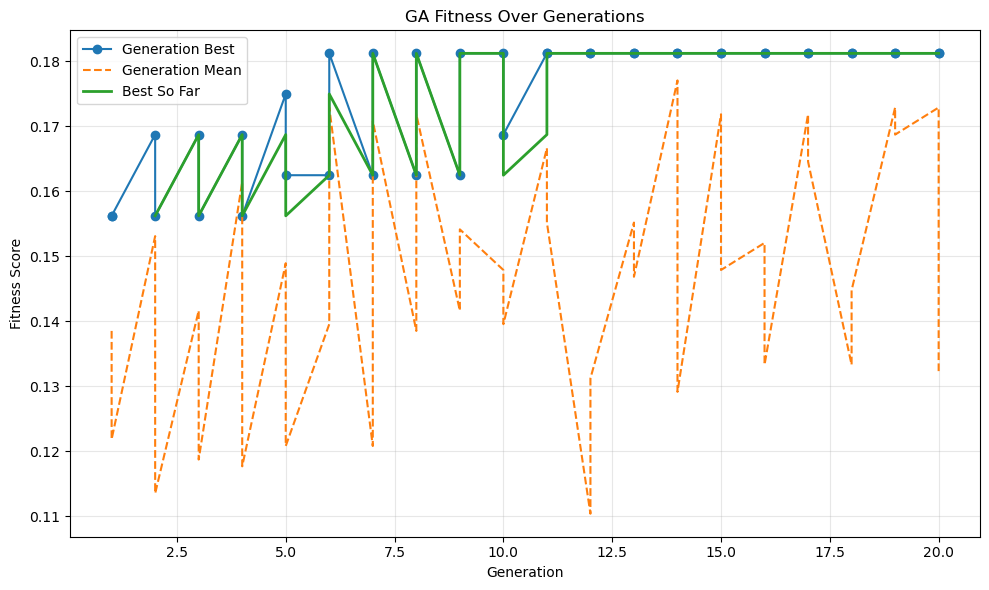

In [29]:
import matplotlib.pyplot as plt

history_csv = run_output_path / "ga_history.csv"
if not history_csv.exists():
    print(f"No ga_history.csv found at {history_csv}")
else:
    df_hist = pd.read_csv(history_csv)
    if df_hist.empty:
        print("ga_history.csv is empty; nothing to plot.")
    else:
        df_hist.sort_values("generation", inplace=True)
        plt.figure(figsize=(10, 6))
        plt.plot(df_hist["generation"], df_hist["gen_best"], label="Generation Best", marker="o")
        if "gen_mean" in df_hist.columns:
            plt.plot(df_hist["generation"], df_hist["gen_mean"], label="Generation Mean", linestyle="--")
        if "best_so_far" in df_hist.columns:
            plt.plot(df_hist["generation"], df_hist["best_so_far"], label="Best So Far", linewidth=2)
        plt.xlabel("Generation")
        plt.ylabel("Fitness Score")
        plt.title("GA Fitness Over Generations")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [24]:
import pandas as pd

In [25]:
best_config_file = run_output_path / "best_config.yaml"
if best_config_file.exists():
    print(best_config_file.read_text())
else:
    print(f"No best_config.yaml found in {run_output_path}")

dtype: bfloat16
merge_method: linear
models:
- model: openai-community/gpt2
  parameters:
    weight: 0.10917749255895615
- model: cwestnedge/gpt2-small-pubmed
  parameters:
    weight: 0.15762174129486084
- model: dbddv01/gpt2-french-small
  parameters:
    weight: 0.0511913076043129


In [20]:
from itertools import islice

def list_directory(path: Path, depth: int = 1, max_entries: int = 50):
    path = Path(path)
    if not path.exists():
        print(f"{path} does not exist")
        return
    print(f"Listing {path} (depth={depth})")
    for entry in islice(sorted(path.iterdir()), 0, max_entries):
        print(entry.relative_to(path.parent))
        if depth > 1 and entry.is_dir():
            for child in islice(sorted(entry.iterdir()), 0, max_entries):
                print(f"  {child.relative_to(path.parent)}")

list_directory(run_output_path, depth=2)

Listing /Users/nkululekothangelane/Documents/master_research/mergekit/workspace/ga-notebook/slm-merge (depth=2)
slm-merge/.DS_Store
slm-merge/baseline_results.csv
slm-merge/best_config.yaml
slm-merge/final_model
  slm-merge/final_model/README.md
  slm-merge/final_model/config.json
  slm-merge/final_model/mergekit_config.yml
  slm-merge/final_model/merges.txt
  slm-merge/final_model/model.safetensors
  slm-merge/final_model/special_tokens_map.json
  slm-merge/final_model/tokenizer.json
  slm-merge/final_model/tokenizer_config.json
  slm-merge/final_model/vocab.json
slm-merge/ga_history.csv
slm-merge/merged
  slm-merge/merged/merged9adx77qd
  slm-merge/merged/mergedezv2r99_
slm-merge/transformers_cache
  slm-merge/transformers_cache/.locks
  slm-merge/transformers_cache/models--cwestnedge--gpt2-small-pubmed
  slm-merge/transformers_cache/models--dbddv01--gpt2-french-small
  slm-merge/transformers_cache/models--openai-community--gpt2
